### Example 1: Numerical tuning and energy conservation for bathymetric refraction

In this example we will simulate a wavepacket propagating over a bumpy bathymetry. The variable depth will cause the wave to refract and focus behind the bump, but the total energy should be conserved.

We first define the domain, bathymetry and initial condition, and then explain some simple heuristics for choosing the resolution, precomputing the DN operator and for setting the absorbing boundary conditions and the temporal step size. These heuristics have proven to be robust for a range of different scenarios. 
 
### Setup

We set the domain size to $L_x = 500$ m and $L_y = 250$, and the bathymetry is given by the function $$ b(X) = 10 - 5e^{-(x - 2L_x/3)^2 - (y - L_y/2)^2}. $$
As initial condition, we take the wave packet 
$$ \eta_0(X) = e^{-(x - L_x/4)^2 - (y - L_y/2)^2}\cos(kx), \quad \varphi_0(X) = 0, $$
with wavenumber $k = \frac{\pi}{10}$ and wavelength $\lambda = \frac{2\pi}{k} = 20$ meters.

Three important choices must now be made, and they are all informed by the (expected) dominant frequency of the waves being simulated. 

### Resolution 

We want to chose a resolution that resolves the shortest wavelengths in our wave field. As a conservative rule of thumb, if we expect the smallest wavelength to $\lambda$, we can take 6-8 grid points per wavelength $ \Delta x  = \Delta y  \leq \frac{\lambda}{6} $. 
With the parameters chosen for this example, we choose $N_x = 256 $ and $N_y = 128$ and then
$$  \Delta x = \Delta y = \frac{L}{N_x} = \frac{L}{N_y} = 1.953...  < \frac{20}{6}.$$

### Dirichlet-to-Neumann operator

Before running the simulation, we precompute the bathymetry dependent DN operator using the method developed in \cite... 
Following their approach, we impose a cut-off wavenumber $k_c$, i.e., a wavenumber such that for fourier modes with wavenumbers $k > k_c$, we do not consider the effect of variable bathymetry. The selection criteria is as follows: let $b_- = \text{ min }b(X)$ and $\bar{b} = (LW)^{-1}\int b(X) \mathrm{d}X$. For a fixed $\delta \ll 1$, one chooses the largest $k^*$ such that 
$$ \frac{\cosh(k^*b_-)}{\sinh(k^*\bar{b})} \leq \delta $$

The criteria discards wave modes with orbital velocoity less than $\delta$ at the shallowest depth. 

Taking $\delta = 0.05$, one finds with our parameters that $k_c \approx 0.6$. The number of Fourier modes used to calculate the depth dependent part of the DN operator is therefore given by 
$$ 
N_{DN} \approx  \frac{k_c L}{2\pi} \approx 46, 
$$ 
and so the fraction of modes used is $ \frac{46^2}{2^{8+7}} = 0.065$. 


### Absorbing boundary conditions

For the absorbing boundary condition we modify our PDE as
$$

    \begin{cases}
        \partial_t \eta +  \nabla_X\cdot(\bar{U} \eta) = \mathcal{G}(b)\varphi -\sigma(X)\eta, \\
        \partial_t \varphi + \bar{U}\cdot \nabla_{X} \varphi = - g\eta - \sigma(X)\varphi.
    \end{cases}
  $$
Here $\sigma(X)$ is the damping coeffient, and is supported on a strip $\Gamma$ of width $d$ near the boundary, with inner boundary $\partial \Gamma_-$ and $\partial \Gamma_+$. Let $s(X)$ be the distance from $\partial \Gamma_-$. A back-of-the envelope WKB calculation in 1D, assuming deep water and no current, and using $\sigma(x) = \sigma_{max}\left(\frac{s(x)}{d}\right)^3$, then shows that the damping ratio is
$$ \frac{\eta|_{\Gamma_+}}{\eta|_{\Gamma_-}} \approx \mathrm{exp}\left(- \frac{\sigma_{max} d \sqrt{k} }{2\sqrt{g}}\right).$$
Next, to choose the with $d$, we note that to make sure the wave is damped,the damping layer should at least be longer than one wavelength. Being conservative, we set $d = 3 \lambda = \frac{6\pi}{k}$ (In general, $d$ should be set w.r.t. the longest wavelength involved). Considering a damping ratio of  $e^{-5} \leq 0.001$ sufficient, then we need to choose $$\sigma_{max} = \frac{5\sqrt{gk}}{2\pi}. $$

In our case, this give $\sigma_{max} \approx 1$. 

### Temporal step size

We require the temporal stepsize to satisfy the RK4 stability criterion $\Delta t \leq \frac{2.78}{M}$ (one can check that this implies stability for all complex eigenvalues), where $M = \text{max}_{n} |\lambda_{n}|$ and $\lambda_n$ are the eigenvalues of the water waves system. Assuming constant current and infinite depth (this maximizes the eigenvalues), we get $$M = \text{max}_{\bm{k} } |i(\bar{U}\cdot \bm{k} \pm \sqrt{g |\bm{k}|})|.$$

In our example the maximal wavenumber has modulus $|\bm{k}| = \pi((N_x/L_x)^2 + (N_y/L_y)^2 )$. We get $M =  \sqrt{g |\bm{k}|} \approx 4.72$ and set take our time step $\Delta t = 0.588$.







Below is code for setting up and running the simulation of the above example, using the DN operator cut-off and absorbing boundary layer parameters as described. 



In [71]:
import numpy as np
import matplotlib.pyplot as plt
import wave_module as wm

%load_ext autoreload
%autoreload 2

# Set Domain and resolution
Lx, Ly = 500, 250 # domain size in x and y directions
Nx, Ny = 2**8, 2**7  # number of grid points in x and y directions
X, Y, dx, dy = wm.build_grid(Lx, Ly, Nx, Ny) 
# Physical parameters
g = 9.81

# Depth profile 
b = 10 - 5*np.exp(-(X-3*Lx/5)**2/(Lx/6)**2-(Y-Ly/2)**2/(Lx/15)**2)
U = np.zeros_like(X), np.zeros_like(X)  # no background current

# Set wave parameters
k0 = np.pi/10  # dominant wavenumber
X0 = Lx/4      # initial wave packet center in x
Y0 = Ly/2      # initial wave packet center in y
eta0 = np.exp(-((X-X0)**2+(Y-Y0)**2)/(Lx/10)**2)*np.cos(k0*(X-Lx/2))  # initial Gaussian wave packet
phi0 = np.zeros_like(eta0)  # initial velocity potential

# Boundary sponge layer parameters
d = 3*2*np.pi/k0  # width of sponge layers
sponge_frac = d/Lx  # fraction of domain used for sponge layers
sigma_max = (5*np.sqrt(g*k0))/(3*np.pi)  # maximum damping coefficient in sponge layers
sponge_sides = "lrtb"  # which sides to apply sponge layers to: l=left, r=right, t=top, b=bottom


# Precompute DN operator

k_c = 0.6
topo_data = wm.precompute_dtn_system(Lx, Ly, Nx, Ny, b, k_cutoff = k_c, flat_bottom=False)


# Time stepping parameters

T_final = 100
dt = 0.5
snapshot_interval = 5



The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
System Setup: 256x128 grid. Active modes: 3576 (10.9%). Mean depth h=9.65.
Matrix Condition Number: 9.33e+02


NameError: name 'mu' is not defined

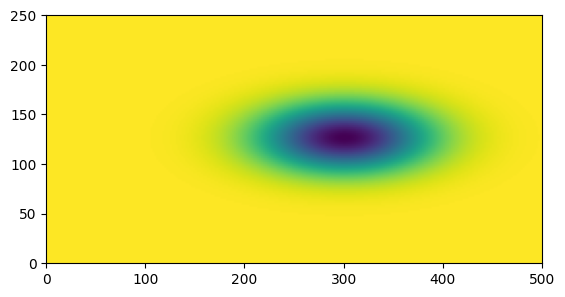

In [57]:
plt.imshow(b, extent=[0,Lx,0,Ly], origin='lower')


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


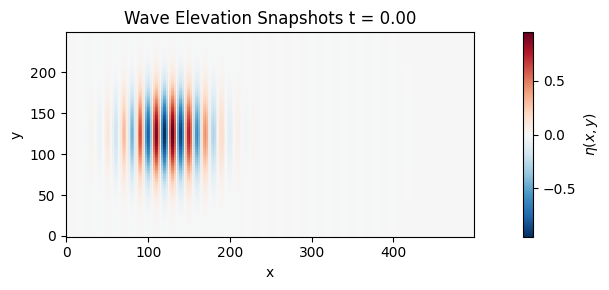

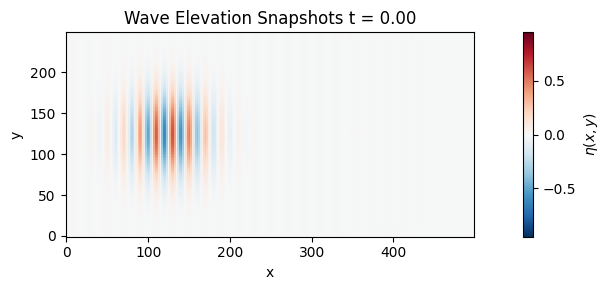

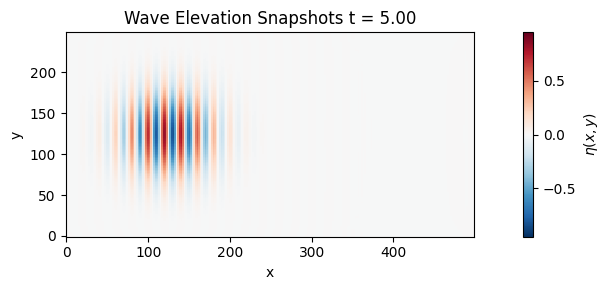

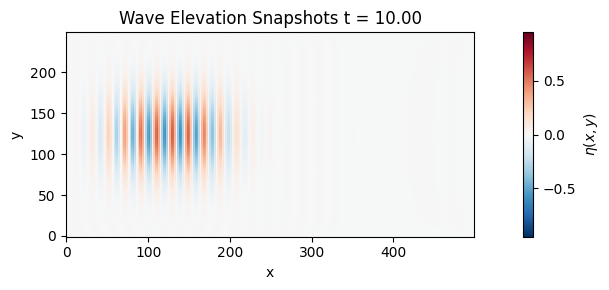

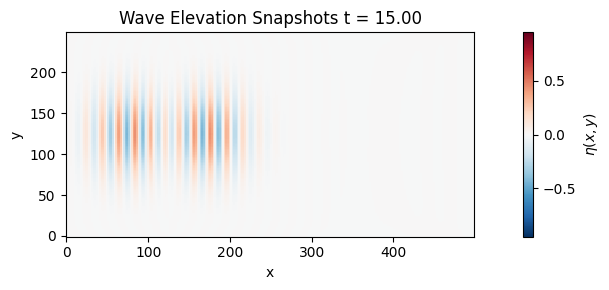

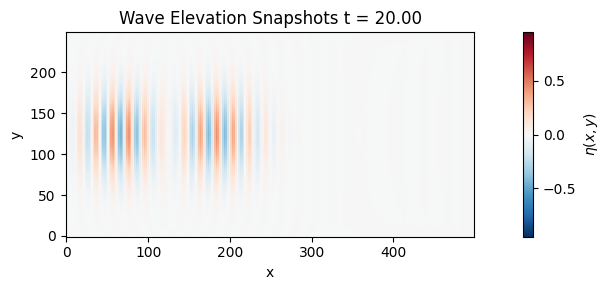

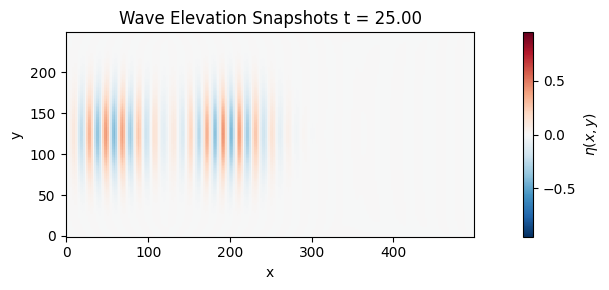

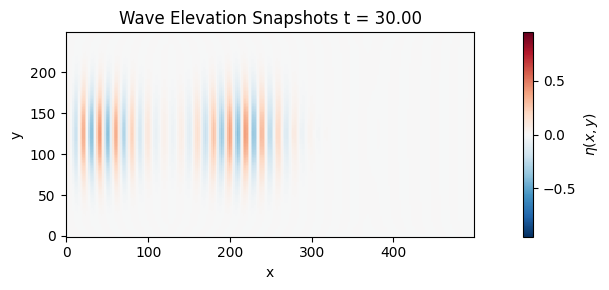

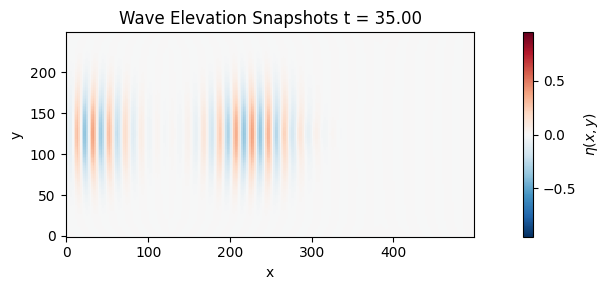

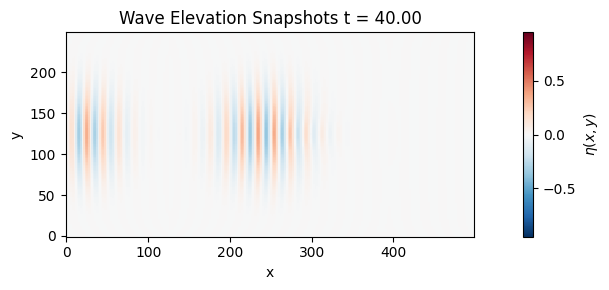

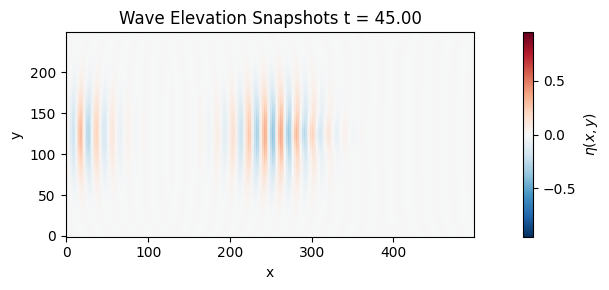

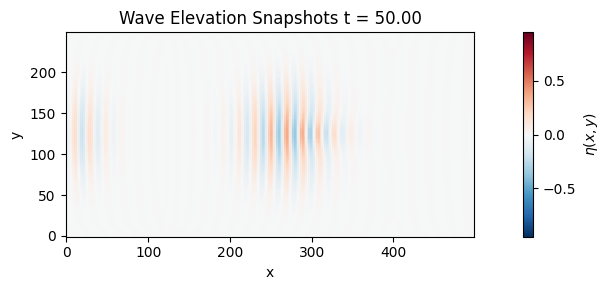

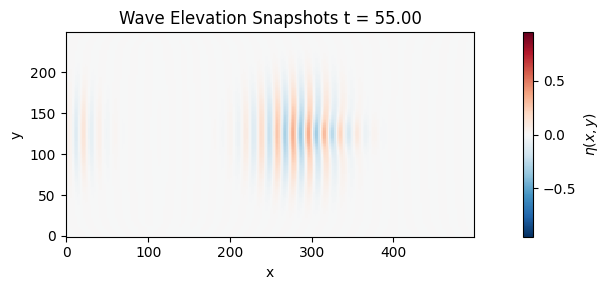

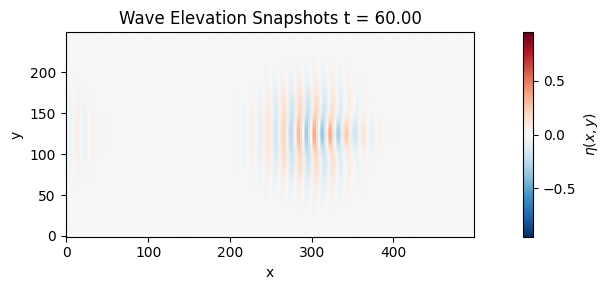

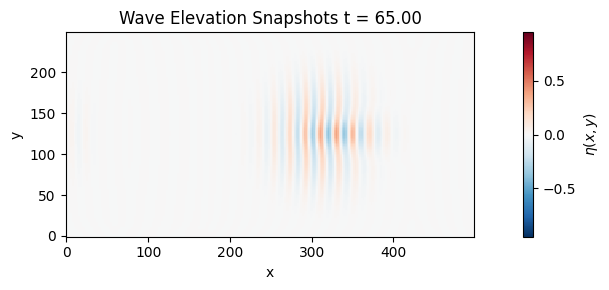

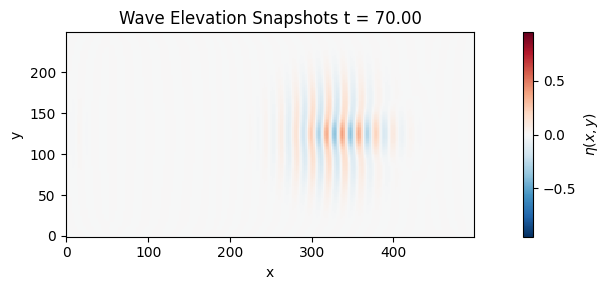

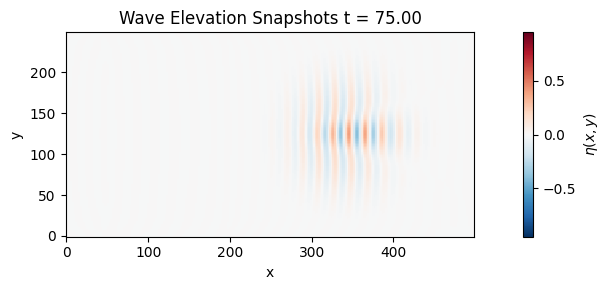

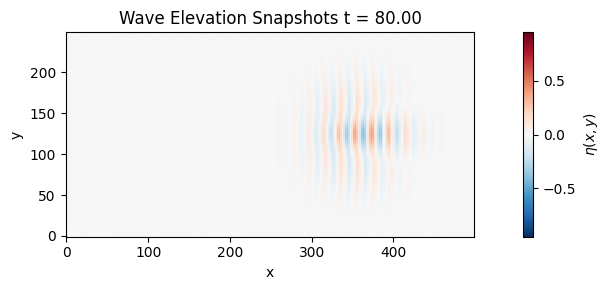

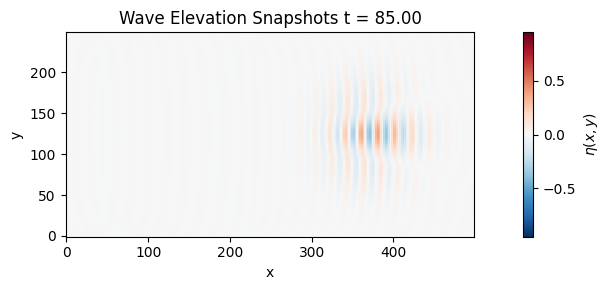

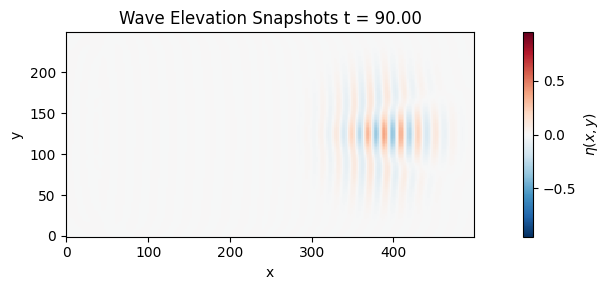

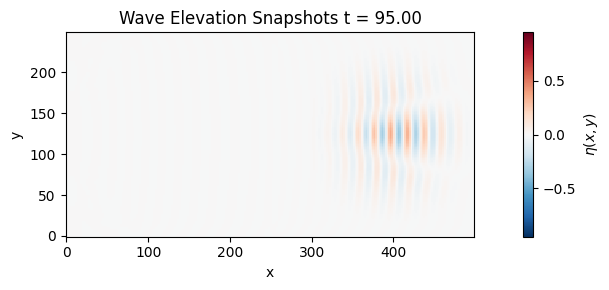

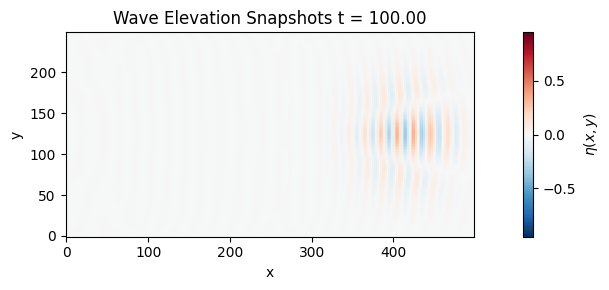

In [68]:
%load_ext autoreload
%autoreload 2
### SIMULATE FULL WAVE MODEL ###

bulk_data = [ ]  # no bulk forcing
energy_domain = [0,Lx,0,Ly]  # compute energy over full domain

t_snaps_w, eta_snaps, phi_snaps,energy_density_snaps, energy_snaps, si_snaps, bi_snaps, (X, Y) = wm.simulate_wave_system(
    Lx, Ly, Nx, Ny,
    T_final, dt,
    eta0, phi0,
    U,
    topo_data,
    bulk_data,
    energy_domain,
    g=9.81,
    sponge_frac =sponge_frac,
    sponge_sides=sponge_sides,
    sigma_max=sigma_max,
    snapshot_interval=snapshot_interval,
    compute_energy_integral=False
)

wm.wave_plots(eta_snaps, 15, X, Y, Lx, Ly, t_list=t_snaps_w, title="Wave Elevation Snapshots")